In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions
from collections import defaultdict
from qiskit.circuit.library import ECRGate



In [ ]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
USE_REAL_DEVICE = True     # Toggle between FakeFez (simulator) and real hardware
BACKEND_NAME = "ibm_fez" # Real hardware name (if USE_REAL_DEVICE = True)

NUM_CIRCUITS = 10
NUM_QUBITS = 10 
DEPTH = 30                    # Depth of the forward circuit U
ENTANGLEMENT_PROBABILITY = 1.0 # p_entangle for creating variance in logical edge usage

NUM_LAYOUTS = 100            # Number of SABRE seeds to try for circuit balancing
NUM_TWIRLS = 20             # Number of Pauli twirls for two-qubit gates
NUM_SHOTS = 10000            # Total shots per circuit



In [ ]:
# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def generate_loschmidt_echo(num_qubits, depth, p_entangle):
    """
    Generates a U^\dagger U Loschmidt echo with variable two-qubit gate counts 
    per edge in the forward pass U. 
    """
    qc = QuantumCircuit(num_qubits)
    
    # Forward Pass (U)
    for d in range(depth):
        for i in range(num_qubits):
            qc.u(np.random.rand()*np.pi, np.random.rand()*np.pi, np.random.rand()*np.pi, i)
        start_idx = d % 2
        for i in range(start_idx, num_qubits - 1, 2):
            if np.random.rand() < p_entangle:
                qc.cx(i, i+1)
                
    # Backward Pass (U^\dagger)
    qc_inv = qc.inverse()
    
    # Combine and measure
    echo_circ = qc.compose(qc_inv)
    echo_circ.measure_all()
    return echo_circ


def count_ecr_on_edges(qc):
    # Dictionary to store counts: (qubit1, qubit2) -> count
    edge_counts = defaultdict(int)
    
    for instruction in qc.data:
        # Check if the operation is an ECRGate
        if isinstance(instruction.operation, ECRGate):
            # Get the qubits involved (usually 2 for ECR)
            qubits = instruction.qubits
            # Convert Qubit objects to indices for identification
            q1 = qc.find_bit(qubits[0]).index
            q2 = qc.find_bit(qubits[1]).index
            
            # Use sorted tuple to ensure (0,1) is the same edge as (1,0)
            edge = tuple(sorted((q1, q2)))
            edge_counts[edge] += 1
            
    return dict(edge_counts)

def get_layout_metrics(transpiled_circ, target):
    """
    Evaluates the circuit balancing cost function.
    Ensures depolarizing parameters are bounded >= 0.
    """
    edge_lambdas = {} 
    edge_counts = {}  
    
    for inst in transpiled_circ.data:
        if inst.operation.num_qubits == 2:
            q0 = transpiled_circ.find_bit(inst.qubits[0]).index
            q1 = transpiled_circ.find_bit(inst.qubits[1]).index
            edge = tuple(sorted((q0, q1))) 
            
            if edge not in edge_lambdas:
                err = None
                try:
                    err = target[inst.operation.name][(q0, q1)].error
                except KeyError:
                    pass
                
                if err is None: 
                    try:
                        err = target[inst.operation.name][(q1, q0)].error
                    except KeyError:
                        pass
                
                if err is None:
                    err = 0.0 
                
                # Convert to lambda and enforce lower bound of 0
                edge_lambdas[edge] = max(0.0, 1.0 - (4.0/3.0) * err)
                edge_counts[edge] = 0
                
            edge_counts[edge] += 1
            
    # Calculate accumulated depolarization for each active edge
    edge_total_deps = [ (edge_lambdas[e] ** edge_counts[e]) for e in edge_counts ]
    
    cost = np.var(edge_total_deps) if edge_total_deps else 0.0
    lambda_global = np.prod(edge_total_deps)**(15/16) if edge_total_deps else 1.0
    
    return cost, lambda_global



<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ayush\AppData\Local\Temp\ipykernel_13052\90412247.py:7: SyntaxWarning: invalid escape sequence '\d'
  Generates a U^\dagger U Loschmidt echo with variable two-qubit gate counts
C:\Users\ayush\AppData\Local\Temp\ipykernel_13052\90412247.py:33: SyntaxWarning: invalid escape sequence '\d'
  Generates a U^\dagger U Loschmidt echo.


In [4]:
# ==============================================================================
# SETUP BACKEND
# ==============================================================================
if USE_REAL_DEVICE:
    service = QiskitRuntimeService()
    backend = service.backend(BACKEND_NAME)
else:
    from qiskit_ibm_runtime.fake_provider import FakeFez
    backend = FakeFez()

target = backend.target



In [5]:
# ==============================================================================
# CIRCUIT GENERATION & BALANCING (SABRE COMPILATION)
# ==============================================================================
print("Generating and compiling Loschmidt echo circuits...")
circuits_default = []
circuits_balanced = []
lambdas_default = []
lambdas_balanced = []

for c_idx in range(NUM_CIRCUITS):
    raw_circ = generate_loschmidt_echo(NUM_QUBITS, DEPTH, ENTANGLEMENT_PROBABILITY)
    #raw_circ = generate_loschmidt_echo(NUM_QUBITS, DEPTH)
    
    best_cost = float('inf')
    best_circ = None
    best_lambda = 1.0
    
    default_circ = None
    default_lambda = 1.0
    
    for seed in range(NUM_LAYOUTS):
        pm = generate_preset_pass_manager(
            optimization_level=2, 
            backend=backend, 
            layout_method="sabre",
            routing_method="sabre",
            seed_transpiler=seed
        )
        t_circ = pm.run(raw_circ)
        cost, lam = get_layout_metrics(t_circ, target)
        
        # Designate the first layout with a non-zero lambda as the default
        if default_circ is None and lam > 0.0:
            default_circ = t_circ
            default_lambda = lam
            
        if cost < best_cost:
            best_cost = cost
            best_circ = t_circ
            best_lambda = lam
            
    # Fallback in the highly unlikely event all seeds had lambda == 0
    if default_circ is None:
        default_circ = best_circ
        default_lambda = best_lambda
            
    circuits_default.append(default_circ)
    lambdas_default.append(default_lambda)
    circuits_balanced.append(best_circ)
    lambdas_balanced.append(best_lambda)



Generating and compiling Loschmidt echo circuits...


In [6]:
# ==============================================================================
# HARDWARE / NOISY EXECUTION (with Twirling and DD)
# ==============================================================================
print("Executing on target backend...")
options = SamplerOptions()
options.default_shots = NUM_SHOTS
options.dynamical_decoupling.enable = True
options.twirling.enable_gates = True
options.twirling.num_randomizations = NUM_TWIRLS
options.twirling.enable_measure = True 

sampler = Sampler(mode=backend, options=options)
job_default = sampler.run(circuits_default)
job_balanced = sampler.run(circuits_balanced)

res_default = job_default.result()
res_balanced = job_balanced.result()



Executing on target backend...


In [ ]:
# ==============================================================================
# DATA PROCESSING & NOISE INVERSION
# ==============================================================================
print("Processing data and applying noise inversion...")
survival_probs = {"Def_NoInv": [], "Bal_NoInv": [], "Bal_Inv": []}

target_state = "0" * NUM_QUBITS
uniform_prob = 1.0 / (2**NUM_QUBITS)

for i in range(NUM_CIRCUITS):
    # Extract ground state return probability for noisy distributions
    counts_def = res_default[i].data.meas.get_counts()
    p_def = counts_def.get(target_state, 0.0) / NUM_SHOTS
    
    counts_bal = res_balanced[i].data.meas.get_counts()
    p_bal = counts_bal.get(target_state, 0.0) / NUM_SHOTS
    
    survival_probs["Def_NoInv"].append(p_def)
    survival_probs["Bal_NoInv"].append(p_bal)
    
    # Apply Noise Inversion to the single probability
    p_def_inv = (p_def - (1.0 - lambdas_default[i]) * uniform_prob) / lambdas_default[i]
    p_bal_inv = (p_bal - (1.0 - lambdas_balanced[i]) * uniform_prob) / lambdas_balanced[i]
    
    # Bound the inverted probabilities between [0, 1]
    survival_probs["Bal_Inv"].append(max(0.0, min(1.0, p_bal_inv)))



Processing data and applying noise inversion...


In [16]:
for t_circ in circuits_default:
    cost, lam = get_layout_metrics(t_circ, target)
    print(cost)

0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269
0.010756706155489269


In [17]:
for t_circ in circuits_balanced:
    cost, lam = get_layout_metrics(t_circ, target)
    print(cost)

6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05
6.16956385196415e-05


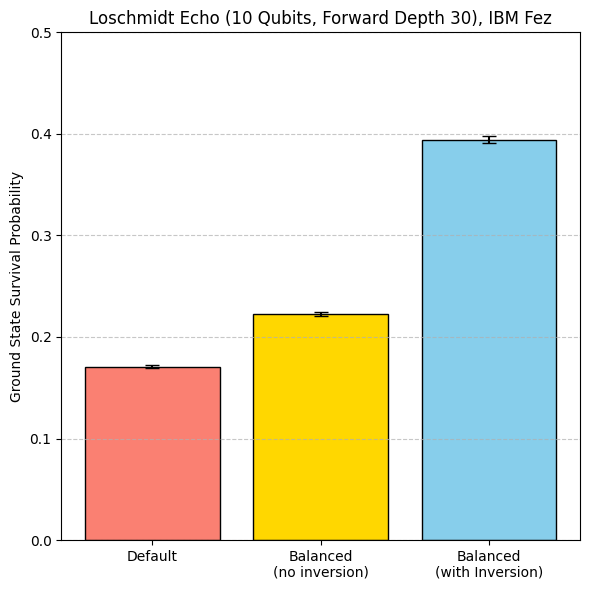

In [27]:
# ==============================================================================
# PLOTTING
# ==============================================================================
labels = ['Default', 'Balanced\n(no inversion)', 'Balanced\n(with Inversion)']
means = [np.mean(survival_probs["Def_NoInv"]), np.mean(survival_probs["Bal_NoInv"]),
          np.mean(survival_probs["Bal_Inv"])]
stderrs = [np.std(survival_probs["Def_NoInv"])/np.sqrt(NUM_CIRCUITS), np.std(survival_probs["Bal_NoInv"])/np.sqrt(NUM_CIRCUITS),
           np.std(survival_probs["Bal_Inv"])/np.sqrt(NUM_CIRCUITS)]

plt.figure(figsize=(6, 6))
bars = plt.bar(labels, means, yerr=stderrs, capsize=5, color=['salmon', 'gold', 'skyblue'], edgecolor='black')

# Ideal Reference Line

plt.ylabel('Ground State Survival Probability')
plt.title(f'Loschmidt Echo ({NUM_QUBITS} Qubits, Forward Depth {DEPTH}), IBM Fez')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0,0.5)

plt.tight_layout()
plt.show()